# Regression Demo
* [Initialization](#scrollTo=TgugYuo_yRLh&line=1&uniqifier=1)
* [Step 1: Data Overview and Initial Analysis](#scrollTo=0Vkz_1CZwcs0&line=1&uniqifier=1)
* [Step 2: Exploratory Data Analysis (EDA)](#scrollTo=SGDkHKUswi2F&line=1&uniqifier=1)
* [Step 3: Data Preprocessing and Feature Engineering](#scrollTo=3hvSW7CLwzuX&line=1&uniqifier=1)
* [Step 4: Splitting the Data into Training and Testing Sets](#scrollTo=ZMWUXtCEw-KN&line=1&uniqifier=1)
* [Step 5: Create and Train Linear Regression Model using Pipeline](#scrollTo=FWAw88GQxDsW&line=1&uniqifier=1)
* [Step 6: Model Predictions](#scrollTo=ip3gxTpBxHSb&line=1&uniqifier=1)
* [Step 7: Evaluation Metrics for Training and Testing Sets](#scrollTo=2YewV2dKxKwv&line=1&uniqifier=1)
* [Step 8: Residual Analysis](#scrollTo=bmG9YHDVxNmv&line=1&uniqifier=1)
* [Step 9: Variance Inflation Factor (VIF) Calculation for Multicollinearity](#scrollTo=nRzVQRQixhrQ&line=1&uniqifier=1)
* [Step 10: Cross-Validation to Evaluate Model Performance](#scrollTo=F99WAbxtxlT5&line=1&uniqifier=1)
* [Step 11: Hyperparameter Tuning with Ridge and Lasso Regression](#scrollTo=wPS67SnDxovo&line=1&uniqifier=1)
* [Step 12: Plotting Predicted vs Actual Values for Test Set](#scrollTo=zEU5Hit0x-GS&line=1&uniqifier=1)
* [Bonus: Statmodels OLS Example](#scrollTo=Z1F7akYa_1Am&line=1&uniqifier=1)

* [Bonus: LASSO Feature Selection Example](#scrollTo=0iOJbqjmGcOh&line=1&uniqifier=1)

# Initialization

In [34]:
# Install necessary packages if not already installed
!pip install openml scikit-learn==1.2.2

In [35]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
import openml
import statsmodels.api as sm
import scipy.stats as stats
from google.colab import drive

In [36]:
# Mount Google Drive to access data if needed
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Load the Ames Housing dataset from OpenML
dataset = openml.datasets.get_dataset(42165)  # Ames Housing dataset ID on OpenML
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

# Ensure reproducibility by setting a random seed
np.random.seed(42)

# Step 1: Data Overview and Initial Analysis

In [38]:
print("Initial Dataset Shape:", X.shape)
display("Feature Overview:\n", X.head())

Initial Dataset Shape: (1460, 80)


'Feature Overview:\n'

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,0,None,None,None,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,0,None,None,None,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,0,None,None,None,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,0,None,None,None,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,0,None,None,None,0,12,2008,WD,Normal


# Step 2: Exploratory Data Analysis (EDA)

## Identify the types of features: categorical vs numerical

In [39]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

## Handle missing values and show missing data count

In [40]:
missing_values = X.isnull().sum().sort_values(ascending=False)
print("Missing Values in Features:\n", missing_values[missing_values > 0])

Missing Values in Features:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageQual        81
GarageCond        81
GarageFinish      81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64


## Plot the distribution of the target variable (SalePrice)

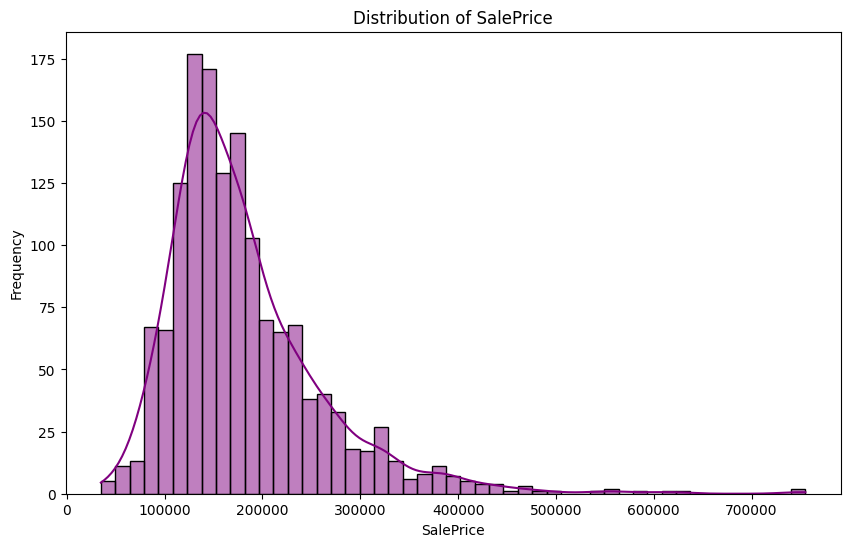

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, color='purple')
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

## Correlation Heatmap for numerical features

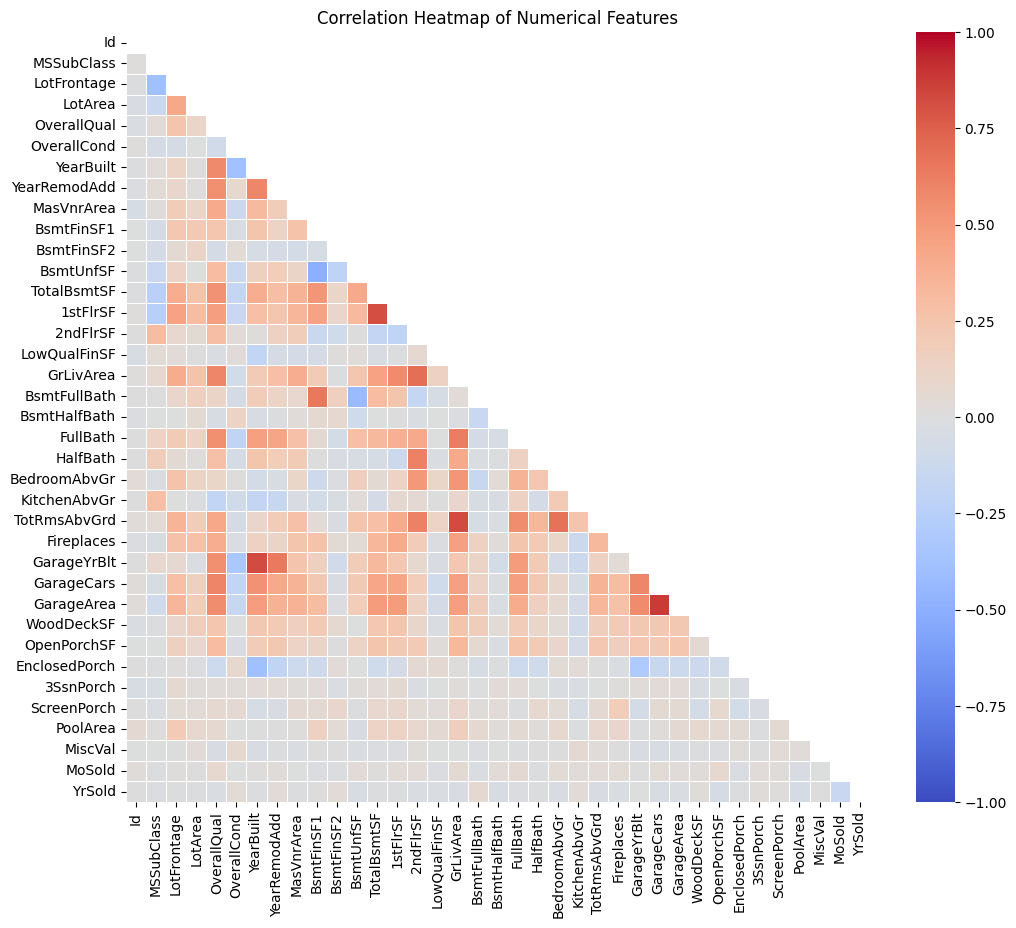

In [42]:
plt.figure(figsize=(12, 10))
#sns.heatmap(X[numerical_features].corr(), annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
#draw triangle matrix
mask = np.triu(np.ones_like(X[numerical_features].corr(), dtype=bool))
sns.heatmap(X[numerical_features].corr(), mask=mask, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Step 3: Data Preprocessing and Feature Engineering

## Create Preprocessing Pipelines for Numerical and Categorical Features

In [43]:
# Step 3: Data Preprocessing and Feature Engineering
# Create Preprocessing Pipelines for Numerical and Categorical Features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

## Combine Transformers into a Preprocessor

In [44]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Step 4: Splitting the Data into Training and Testing Sets

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Create and Train Linear Regression Model using Pipeline

In [46]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Id', 'MSSubClass',
                                                   'LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'YearBuilt', 'YearRemodAdd',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   '2ndFlrSF', 'LowQualFinSF',
                                                   'GrLi...
                                                   'LandContour', 'Utilities',
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model', LinearRegression())])

# Step 6: Model Predictions

In [47]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# Step 7: Evaluation Metrics for Training and Testing Sets

In [48]:
def evaluate_model(y_true, y_pred, dataset_type="Training"):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    print(f"{dataset_type} Set Performance:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-Squared (R²): {r2:.2f}")
    print(f"Explained Variance Score: {explained_var:.2f}\n")

evaluate_model(y_train, y_train_pred, dataset_type="Training")
evaluate_model(y_test, y_test_pred, dataset_type="Testing")


Training Set Performance:
Mean Squared Error (MSE): 357030937.93
Mean Absolute Error (MAE): 12122.89
R-Squared (R²): 0.94
Explained Variance Score: 0.94

Testing Set Performance:
Mean Squared Error (MSE): 4262044743.67
Mean Absolute Error (MAE): 21108.03
R-Squared (R²): 0.44
Explained Variance Score: 0.45



# Step 8: Residual Analysis

## Residual Sum of Squares (RSS)

In [49]:
rss_train = np.sum(np.square(y_train - y_train_pred))
rss_test = np.sum(np.square(y_test - y_test_pred))
print("Residual Sum of Squares (RSS):")
print(f"Training Set RSS: {rss_train:.2f}")
print(f"Test Set RSS: {rss_test:.2f}\n")

Residual Sum of Squares (RSS):
Training Set RSS: 417012135501.15
Test Set RSS: 1244517065151.80



## Residuals Plot for Test Set


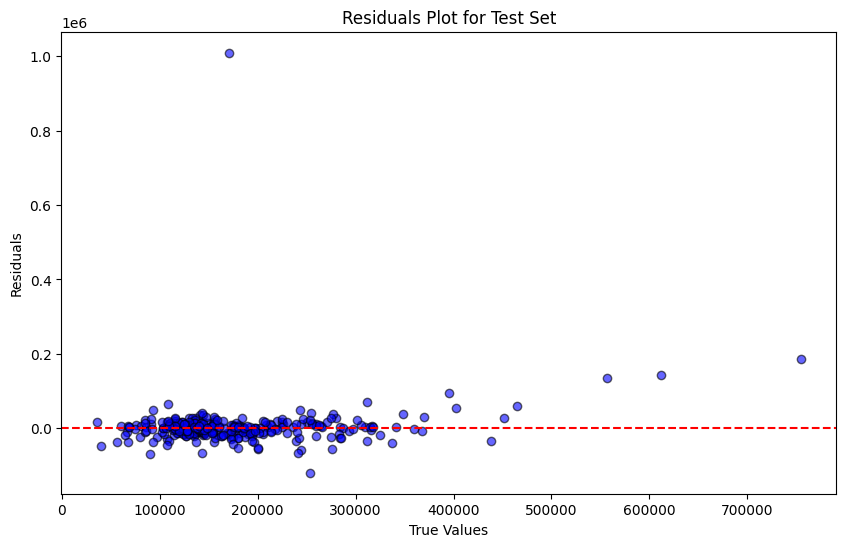

In [50]:
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, color='blue', edgecolor='k', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot for Test Set')
plt.show()

## Distribution of Residuals

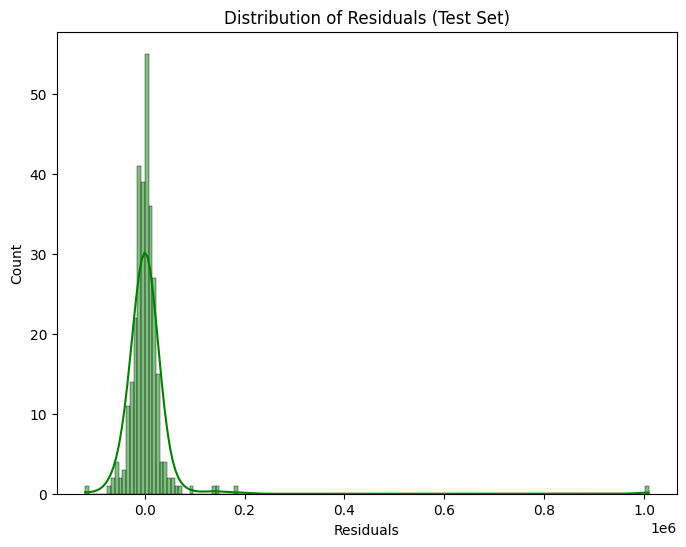

In [51]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='green')
plt.title('Distribution of Residuals (Test Set)')
plt.xlabel('Residuals')
plt.show()

## Q-Q Plot for Residuals

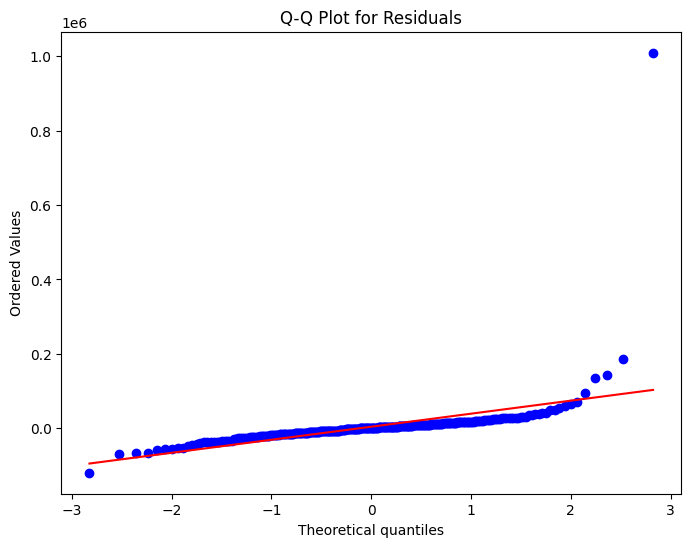

In [52]:

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot for Residuals')
plt.show()

## Criteria for Validating Residual Distribution with Numerical Analysis


In [53]:
residual_mean = np.mean(residuals)
residual_std = np.std(residuals)
residual_skew = stats.skew(residuals)
residual_kurtosis = stats.kurtosis(residuals)

print("Numerical Criteria for Validating Residuals:")
print(f"Mean of Residuals: {residual_mean:.2f} (Should be close to 0)")
print(f"Standard Deviation of Residuals: {residual_std:.2f} (Should be relatively small)")
print(f"Skewness of Residuals: {residual_skew:.2f} (Should be close to 0 for normal distribution)")
print(f"Kurtosis of Residuals: {residual_kurtosis:.2f} (Should be close to 0 for normal distribution)")

Numerical Criteria for Validating Residuals:
Mean of Residuals: 4261.98 (Should be close to 0)
Standard Deviation of Residuals: 65145.07 (Should be relatively small)
Skewness of Residuals: 12.67 (Should be close to 0 for normal distribution)
Kurtosis of Residuals: 191.54 (Should be close to 0 for normal distribution)


# Step 9: Variance Inflation Factor (VIF) Calculation for Multicollinearity

In [54]:
X_train_processed_vif = pd.DataFrame(preprocessor.fit_transform(X_train).toarray(), columns=preprocessor.get_feature_names_out())  # Ensure dense format for VIF calculation with feature names

# Drop any columns with zero variance to avoid VIF calculation issues
non_zero_variance_columns = X_train_processed_vif.var() > 0
X_train_processed_vif = X_train_processed_vif.loc[:, non_zero_variance_columns]

# Ensure all columns are numeric
X_train_processed_vif = X_train_processed_vif.apply(pd.to_numeric)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_processed_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_processed_vif.values, i)
                    for i in range(X_train_processed_vif.shape[1])]
print("Variance Inflation Factor (VIF) for Features:")
print(vif_data)


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Variance Inflation Factor (VIF) for Features:
                        Feature        VIF
0                       num__Id   1.286208
1               num__MSSubClass  55.537867
2              num__LotFrontage   2.896615
3                  num__LotArea   5.396668
4              num__OverallQual   5.853327
..                          ...        ...
298  cat__SaleCondition_AdjLand        inf
299   cat__SaleCondition_Alloca        inf
300   cat__SaleCondition_Family        inf
301   cat__SaleCondition_Normal        inf
302  cat__SaleCondition_Partial        inf

[303 rows x 2 columns]


In [55]:
# sort and remove inf
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False)
vif_data_sorted = vif_data_sorted[vif_data_sorted['VIF'] != np.inf]

display(vif_data_sorted)

,Feature,VIF
33,num__PoolArea,3657.444010
1,num__MSSubClass,55.537867
34,num__MiscVal,29.476035
6,num__YearBuilt,16.518625
27,num__GarageArea,8.658326
26,num__GarageCars,8.650481
24,num__Fireplaces,8.251036
23,num__TotRmsAbvGrd,7.440346
25,num__GarageYrBlt,6.290250
4,num__OverallQual,5.853327


# Step 10: Cross-Validation to Evaluate Model Performance


In [56]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cross_val_mse = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')
cross_val_r2 = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')
cross_val_mae = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')

print("Cross-Validation Results:")
print(f"Average Cross-Validation MSE: {-np.mean(cross_val_mse):.2f}")
print(f"Average Cross-Validation R-Squared: {np.mean(cross_val_r2):.2f}\n")
print(f"Average Cross-Validation MAE: {-np.mean(cross_val_mae):.2f}")

Cross-Validation Results:
Average Cross-Validation MSE: 1896398369.76
Average Cross-Validation R-Squared: 0.69

Average Cross-Validation MAE: 18872.12


# Step 11: Hyperparameter Tuning with Ridge and Lasso Regression

## Ridge Regression Tuning

In [57]:
ridge_params = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', Ridge())])

ridge_search = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='neg_mean_squared_error')

ridge_search.fit(X_train, y_train)
print(f"Best Alpha for Ridge: {ridge_search.best_params_['model__alpha']}")
print(f"Best Ridge Model MSE: {-ridge_search.best_score_:.2f}\n")

Best Alpha for Ridge: 10.0
Best Ridge Model MSE: 1153809650.52



## Lasso Regression Tuning

In [58]:
lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1.0]}
lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', Lasso())])
lasso_search = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_search.fit(X_train, y_train)

print(f"Best Alpha for Lasso: {lasso_search.best_params_['model__alpha']}")
print(f"Best Lasso Model MSE: {-lasso_search.best_score_:.2f}\n")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 149967143950.12857, tolerance: 537415025.1745832
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 131945966710.42636, tolerance: 572016182.2224231
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 152780461370.61813, tolerance: 525605188.80204767
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: Conv

Best Alpha for Lasso: 1.0
Best Lasso Model MSE: 1168016964.95



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 210751469367.5755, tolerance: 696659484.3571944
  model = cd_fast.sparse_enet_coordinate_descent(


In [59]:

numerical_features = lasso_search.best_estimator_.named_steps['preprocessor'].transformers[0][2]
categorical_features =  lasso_search.best_estimator_.named_steps['preprocessor'].transformers[1][2]
# Get the OneHotEncoder from the pipeline
encoder = lasso_search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']

# Retrieve the one-hot encoded feature names
encoded_categorical_features = lasso_search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(encoded_categorical_features)

In [60]:
# Get the coefficients from the Lasso model
coefficients = lasso_search.best_estimator_.named_steps['model'].coef_

# Get the intercept from the Lasso model
intercept = lasso_search.best_estimator_.named_steps['model'].intercept_

In [61]:
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Optionally, sort the DataFrame by the absolute value of coefficients
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

# Reset index for clarity
coef_df.reset_index(drop=True, inplace=True)

# Display the DataFrame
display(coef_df)

,Feature,Coefficient
0,PoolQC_Gd,-466856.702475
1,PoolQC_Fa,-384384.211356
2,RoofMatl_ClyTile,-382491.865427
3,PoolQC_None,335596.623534
4,Condition2_PosN,-226169.016869
...,...,...
298,BldgType_Duplex,0.000000
299,PavedDrive_Y,0.000000
300,LotConfig_Inside,-0.000000
301,BsmtFinType1_Rec,-0.000000


<ipython-input-62-a46cb977e699>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='viridis')


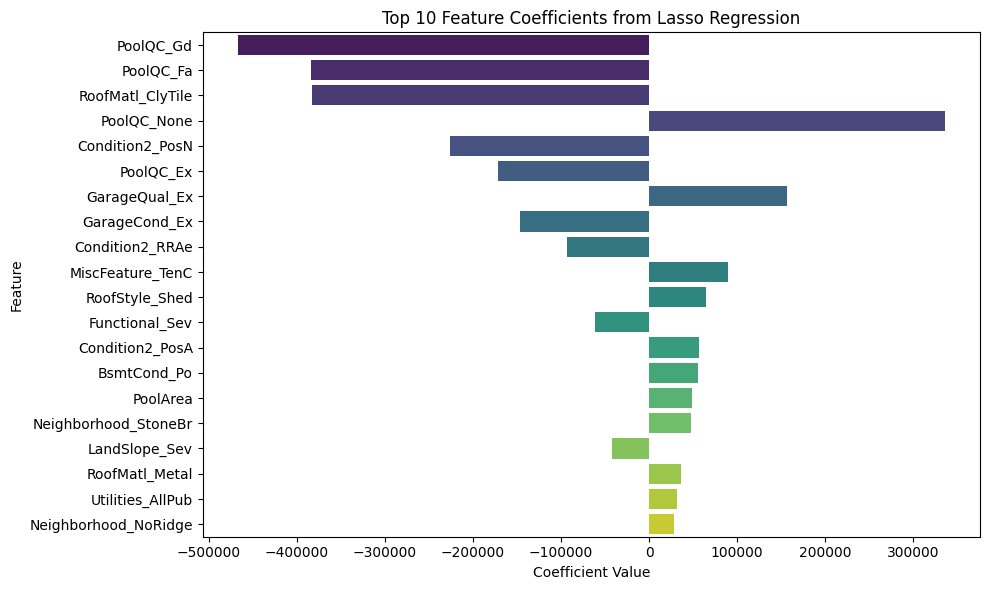

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the top 10 features by absolute coefficient value
top_features = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='viridis')
plt.title('Top 10 Feature Coefficients from Lasso Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The intercept represents the expected value of the target variable when all features are zero.

In [ ]:
print(f"Intercept: {intercept}")

# Step 12: Plotting Predicted vs Actual Values for Test Set

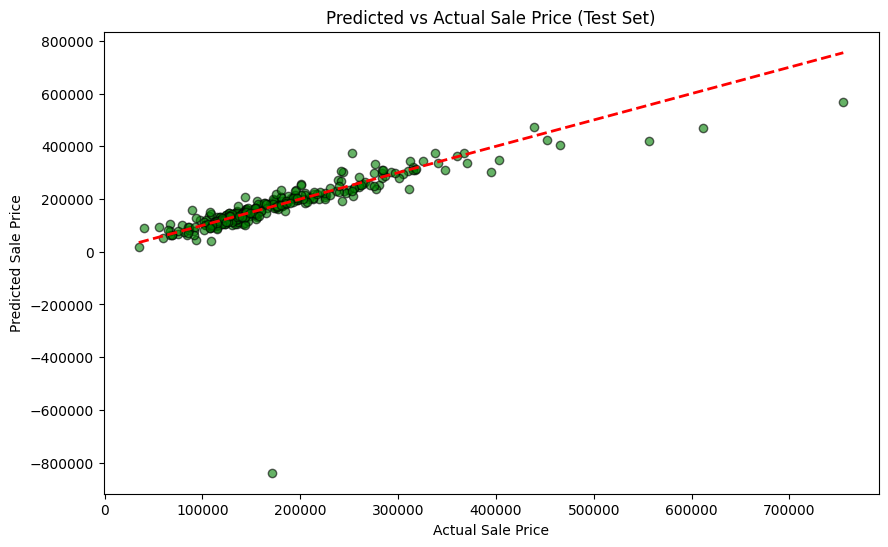

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='green', edgecolor='k', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Predicted vs Actual Sale Price (Test Set)')
plt.show()

# Statmodels OLS Example

Initial Dataset Shape: (1460, 80)

First five rows of the dataset:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave  None      Reg   
1   2          20       RL         80.0     9600   Pave  None      Reg   
2   3          60       RL         68.0    11250   Pave  None      IR1   
3   4          70       RL         60.0     9550   Pave  None      IR1   
4   5          60       RL         84.0    14260   Pave  None      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC Fence MiscFeature  \
0         Lvl    AllPub  ...           0        0   None  None        None   
1         Lvl    AllPub  ...           0        0   None  None        None   
2         Lvl    AllPub  ...           0        0   None  None        None   
3         Lvl    AllPub  ...           0        0   None  None        None   
4         Lvl    AllPub  ...           0        0   None  None        None   

  MiscVal MoSold  Y

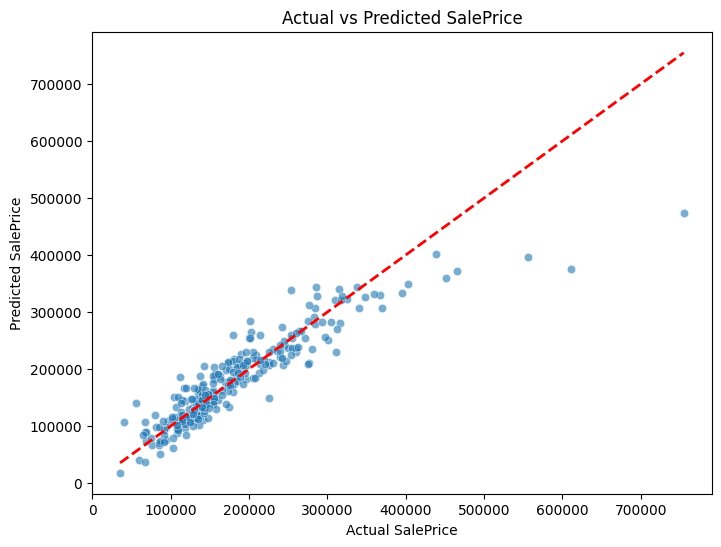

In [64]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Step 1: Load the Ames Housing Dataset from OpenML
# ---------------------------------------------------
# Dataset ID for Ames Housing on OpenML is 42165
dataset = openml.datasets.get_dataset(42165)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

# Display the first few rows of the dataset
print("Initial Dataset Shape:", X.shape)
print("\nFirst five rows of the dataset:")
print(X.head())

# Step 2: Identify Numerical and Categorical Features
# ----------------------------------------------------
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("\nNumber of Categorical Features:", len(categorical_features))
print("Categorical Features:", categorical_features[:10], "...")  # Display first 10 for brevity
print("\nNumber of Numerical Features:", len(numerical_features))
print("Numerical Features:", numerical_features[:10], "...")  # Display first 10 for brevity

# Step 3: Data Preprocessing and Feature Selection
# -------------------------------------------------
# For simplicity, we'll select a subset of features
# You can expand this list based on your analysis
selected_numerical = ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
selected_categorical = ['Neighborhood', 'HouseStyle', 'Exterior1st', 'SaleCondition']

# Combine selected features
selected_features = selected_numerical + selected_categorical

# Ensure selected features exist in the dataset
selected_features = [feature for feature in selected_features if feature in X.columns]

# Update feature lists
numerical_features = selected_numerical
categorical_features = selected_categorical

# Create Preprocessing Pipelines for Numerical and Categorical Features
# -----------------------------------------------------------------------
# Numerical Transformer: Impute missing values with mean
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
    # ('scaler', StandardScaler())  # Optional: Add scaling if needed
])

# Categorical Transformer: Impute missing values with most frequent and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # Updated parameter
])

# Combine Transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Step 4: Splitting the Data into Training and Testing Sets
# ----------------------------------------------------------
# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# Step 5: Apply Preprocessing to the Training Data
# -------------------------------------------------
# Fit the preprocessor on the training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Retrieve feature names after one-hot encoding
# For numerical features, names remain the same
# For categorical features, get the new one-hot encoded feature names
onehot_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(onehot_feature_names)

# Convert the processed array back to a DataFrame with feature names and original indices
X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)

# Add a constant term for the intercept
X_train_processed = sm.add_constant(X_train_processed)

# Step 6: Fit the OLS Model using statsmodels
# -------------------------------------------
# Ensure that the indices of y_train and X_train_processed align
assert y_train.index.equals(X_train_processed.index), "Indices of y_train and X_train_processed do not align."

# Define the dependent variable
y_train_sm = y_train

# Define the independent variables (already includes constant)
X_train_sm = X_train_processed

# Fit the OLS model
ols_model = sm.OLS(y_train_sm, X_train_sm).fit()

# Step 7: Display the Regression Summary
# ---------------------------------------
print("\nOLS Regression Results:")
print(ols_model.summary())

# Step 8: Making Predictions and Evaluating the Model on Test Data
# -----------------------------------------------------------------
# Preprocess the test data using the already fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Convert to DataFrame with feature names and original indices
X_test_processed = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

# Add constant term
X_test_processed = sm.add_constant(X_test_processed)

# Predict using the OLS model
y_test_pred = ols_model.predict(X_test_processed)

# Calculate Evaluation Metrics
mse = np.mean((y_test - y_test_pred) ** 2)
rmse = np.sqrt(mse)
r_squared = ols_model.rsquared

print("\nModel Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared: {r_squared:.2f}")

# Optional: Plot Actual vs Predicted Values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.show()



# Key Metrics and Their Interpretation

## a. R-squared and Adjusted R-squared

### **R-squared:**
- **Definition:**  
  Measures the proportion of variance in the dependent variable that's explained by the independent variables.

- **Interpretation:**  
  An R-squared of **0.815** means that **81.5%** of the variability in the target variable is explained by the model. Higher values indicate a better fit.

### **Adjusted R-squared:**
- **Definition:**  
  Adjusts the R-squared value based on the number of predictors in the model.

- **Interpretation:**  
  An Adjusted R-squared of **0.806** accounts for the number of predictors, penalizing for adding non-significant variables. It provides a more accurate measure when comparing models with different numbers of predictors.

## b. F-statistic and Prob (F-statistic)

### **F-statistic:**
- **Definition:**  
  Tests the overall significance of the model.

- **Interpretation:**  
  A high F-statistic value (e.g., **89.09**) with a corresponding **Prob (F-statistic)** close to **0.00** indicates that the model is statistically significant, meaning at least one predictor is significantly related to the target variable.

## c. Coefficients, Standard Errors, t-values, and P-values

### **Coefficients (coef):**
- **Definition:**  
  Represent the expected change in the dependent variable for a one-unit change in the predictor, holding other predictors constant.

- **Interpretation:**  
  - **Positive Coefficient:** Indicates a positive relationship between the predictor and the target variable.
  - **Negative Coefficient:** Indicates a negative relationship.

### **Standard Errors (std err):**
- **Definition:**  
  Measure the variability of the coefficient estimates.

### **t-values and P-values (P>|t|):**
- **Definition:**  
  Assess the significance of individual predictors.

- **Interpretation:**  
  - **Low P-value (< 0.05):** Predictor is statistically significant.
  - **High P-value (≥ 0.05):** Predictor is not statistically significant.

### **Confidence Intervals ([0.025, 0.975]):**
- **Definition:**  
  Range within which the true coefficient value is expected to lie with 95% confidence.

- **Interpretation:**  
  If the interval does not include zero, the predictor is considered significant.

## d. Condition Number

- **Definition:**  
  Measures multicollinearity in the model.

- **Interpretation:**  
  A high condition number (typically > 30) suggests strong multicollinearity or numerical instability, which can inflate the variance of coefficient estimates and make the model unreliable.

## e. Residual Diagnostics

### **Durbin-Watson:**
- **Definition:**  
  Tests for autocorrelation in residuals.

- **Interpretation:**  
  Values close to **2** indicate no autocorrelation. Values approaching **0** or **4** suggest positive or negative autocorrelation, respectively.

### **Omnibus, Prob(Omnibus), Jarque-Bera (JB), Prob(JB), Skew, Kurtosis:**
- **Definition:**  
  Assess the normality of residuals.

- **Interpretation:**  
  - **Prob (Omnibus) and Prob(JB):** Low values (< 0.05) indicate non-normal residuals.
  - **Skew and Kurtosis:** Values close to **0** suggest symmetric distribution and normality, respectively.

---

# 3. Interpreting the Regression Coefficients

Each coefficient in the regression output provides insights into the relationship between a predictor and the target variable.

## a. Significant Predictors (p < 0.05)

### **Positive Coefficient:**
- Indicates that as the predictor increases, the target variable increases.

### **Negative Coefficient:**
- Indicates that as the predictor increases, the target variable decreases.

### **Magnitude of Coefficient:**
- Reflects the strength of the relationship. Larger absolute values indicate a stronger impact on the target variable.

### **Example Interpretation:**

- **Predictor1 (coef: 58.0087, p < 0.000):**  
  For each one-unit increase in Predictor1, the target variable increases by **58.01 units**, holding other factors constant. This predictor is highly significant.

- **Predictor2 (coef: 16,240, p < 0.000):**  
  For each one-unit increase in Predictor2, the target variable increases by **\$16,240**, holding other factors constant. This predictor is highly significant.

## b. Insignificant Predictors (p ≥ 0.05)

### **Lack of Significance:**
- Predictors with high p-values are not statistically significant and may not contribute meaningfully to the model.

### **Potential Actions:**
- Consider removing these predictors to simplify the model and reduce multicollinearity.

### **Example Interpretation:**

- **PredictorX (coef: 6,824.928, p = 0.985):**  
  This predictor is not statistically significant, suggesting no meaningful relationship with the target variable in the presence of other variables.



# Bonus: Lasso feature selection

First Five Rows of the Synthetic Dataset:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0   0.496714  -0.138264   0.647689   1.523030  -0.234153  -0.234137   
1  -0.463418  -0.465730   0.241962  -1.913280  -1.724918  -0.562288   
2   1.465649  -0.225776   0.067528  -1.424748  -0.544383   0.110923   
3  -0.601707   1.852278  -0.013497  -1.057711   0.822545  -1.220844   
4   0.738467   0.171368  -0.115648  -0.301104  -1.478522  -0.719844   

   Feature_7  Feature_8  Feature_9  Feature_10    Target  
0   1.579213   0.767435  -0.469474    0.542560  0.771909  
1  -1.012831   0.314247  -0.908024   -1.412304 -3.705233  
2  -1.150994   0.375698  -0.600639   -0.291694  7.377320  
3   0.208864  -1.959670  -1.328186    0.196861 -5.733197  
4  -0.460639   1.057122   0.343618   -1.763040  2.948701  

Training Set Shape: (80, 10)
Testing Set Shape: (20, 10)

Lasso Coefficients:
      Feature  Coefficient
0   Feature_1     4.354542
1   Feature_2    -0.000000
2   Feature_3    

<ipython-input-65-a5f0b5b9b990>:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


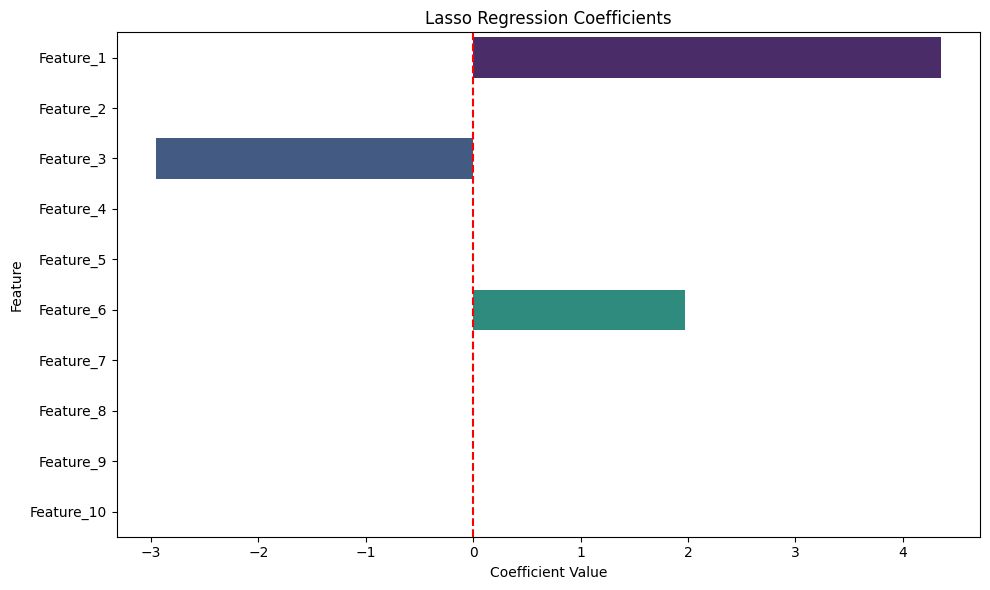


OLS Coefficients:
      Feature  Coefficient
0   Feature_1     4.450762
1   Feature_2    -0.013045
2   Feature_3    -3.051954
3   Feature_4     0.029842
4   Feature_5    -0.064794
5   Feature_6     2.032647
6   Feature_7    -0.124145
7   Feature_8     0.034636
8   Feature_9     0.015099
9  Feature_10    -0.000257


<ipython-input-65-a5f0b5b9b990>:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=ols_coef_df, palette='magma')


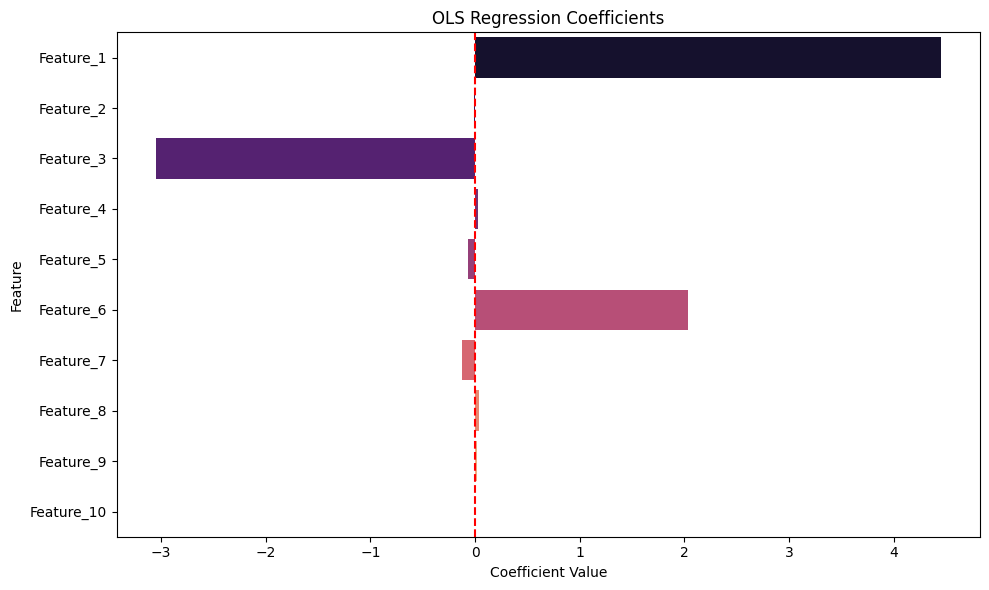

In [65]:

import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Number of samples and features
n_samples = 100
n_features = 10

# Generate feature matrix with random values
X = np.random.randn(n_samples, n_features)

# Define true coefficients for only 3 features
true_coefs = np.array([5, 0, -3, 0, 0, 2, 0, 0, 0, 0])

# Generate target variable with some noise
noise = np.random.randn(n_samples) * 0.5
y = X.dot(true_coefs) + noise

# Create a pandas DataFrame for better visualization
feature_names = [f"Feature_{i}" for i in range(1, n_features + 1)]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

# Display first five rows
print("First Five Rows of the Synthetic Dataset:")
print(df.head())

# Define features and target
X = df.drop('Target', axis=1)
y = df['Target']

# Split into training and testing (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Lasso with a chosen alpha
lasso = Lasso(alpha=0.1, random_state=42)

# Fit Lasso model
lasso.fit(X_train_scaled, y_train)

# Retrieve coefficients
lasso_coefs = lasso.coef_

# Create a DataFrame for coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefs
})

print("\nLasso Coefficients:")
print(coef_df)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Lasso Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

from sklearn.linear_model import LinearRegression

# Initialize and fit OLS model
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Retrieve OLS coefficients
ols_coefs = ols.coef_

# Create a DataFrame for OLS coefficients
ols_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ols_coefs
})

print("\nOLS Coefficients:")
print(ols_coef_df)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=ols_coef_df, palette='magma')
plt.title('OLS Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()
